#### Impact of Hypothesis 1 violations on the completeness of Algorithm 2 (Corollary 2)

For each run we compute the oracle $\theta_{\mathcal{G}}=\min\{\theta\in\mathcal{G}:B_{\delta/J}(\theta)\le r^*\}$
and the threshold returned by Algorithm 2, and call the run complete when the two coincide. Runs
where $\Theta=\emptyset$ are not counted, Corollary 2 assuming $\Theta\neq\emptyset$. Both sides read
off the same bound path, so unlike the validity of the guarantee this is directly testable.

In [7]:
%run -i ../python_scripts/nb_setup.py

In [8]:
METRIC = "FPR"
THETA_MIN, THETA_MAX = 0, 1
RANKINGS = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 2, 4, 6, 20, np.inf]
SIZES = np.arange(500, 20000, 3000)
NUM_SEEDS = 50
R_STARS = [0.08, 0.10, 0.12]
PLOT_R_STAR = 0.10

In [9]:
rows = []
for n in SIZES:
    for ranking in tqdm(RANKINGS, desc=f"n={n}"):
        for seed in range(NUM_SEEDS):
            sim = simulate_sgp_dataset(n, ranking=ranking, seed=seed)
            # raw path (keeps the vacuous records halting each scan), reused across targets
            path = sgp_multistart_search(
                DELTA, None, sim, METRIC, theta_min=THETA_MIN, theta_max=THETA_MAX
            )
            _, auc_emp, _ = h1_transport(sim, METRIC)
            for r_star in R_STARS:
                rec = completeness_record(path, r_star, METRIC)
                if rec is None:  # no threshold of the grid meets r*, nothing to compare
                    continue
                rec.update(n=n, ranking=ranking, seed=seed, auc_emp=auc_emp)
                rows.append(rec)
res = pd.DataFrame(rows)
res["discordant"] = 100 * (1 - res.auc_emp)
# NaN on the uncounted runs, so groupby means are taken among non-empty Theta
res["complete"] = np.where(res.status.eq("empty"), np.nan, res.status.eq("exact"))

n=18500: 100%|██████████| 12/12 [01:34<00:00,  7.84s/it]


In [10]:
assert res[np.isinf(res.ranking)].complete.min() == 1, "Corollary 2 broken under (H1)"
print(res.status.value_counts().to_dict())
cols = ["discordant", "complete", "gap_steps", "coverage_loss", "contiguous"]
display(res.groupby(["r_star", "ranking"])[cols].mean().round(4))

{'exact': 8810, 'empty': 271, 'suboptimal': 78}


discordant  complete  gap_steps  coverage_loss  contiguous
r_star ranking                                                            
0.08   0.5         27.6673    0.9709     0.0631         0.0032      0.9708
       0.7         21.4139    0.9926     0.0221         0.0010      0.9866
       0.9         16.5362    0.9899     0.0304         0.0007      0.9836
       1.1         12.9227    0.9934     0.0197         0.0004      0.9872
       2.0          5.2296    0.9651     0.1599         0.0027      0.9397
       4.0          1.4482    0.9943     0.0171         0.0002      0.9914
       6.0          0.6551    0.9943     0.0257         0.0002      0.9914
       20.0         0.0605    1.0000     0.0000         0.0000      1.0000
       inf          0.0000    1.0000     0.0000         0.0000      1.0000
0.10   0.3         35.2957    1.0000     0.0000         0.0000      1.0000
       0.5         27.7175    0.9725     0.0863         0.0041      0.9688
       0.7         21.3737    0.9966     0.0102         0.0002      0.9967
       0.9         16.4626    0.9967     0.0065         0.0001      0.9873
       1.1         12.9411    0.9875     0.0562         0.0009      0.9525
       2.0          5.2431    0.9857     0.0602         0.0007      0.9714
       4.0          1.4482    0.9914     0.0286         0.0002      0.9886
       6.0          0.6551    0.9971     0.0057         0.0000      0.9971
       20.0         0.0605    1.0000     0.0000         0.0000      1.0000
       inf          0.0000    1.0000     0.0000         0.0000      1.0000
0.12   0.3         35.5533    0.9398     0.1353         0.0071      0.9371
       0.5         27.7408    0.9819     0.1014         0.0042      0.9669
       0.7         21.3465    1.0000     0.0000         0.0000      0.9968
       0.9         16.5313    0.9905     0.0286         0.0006      0.9760
       1.1         12.9681    0.9759     0.0904         0.0016      0.9448
       2.0          5.2431    0.9943     0.0143         0.0001      0.9914
       4.0          1.4482    0.9971     0.0057         0.0001      0.9971
       6.0          0.6551    1.0000     0.0000         0.0000      1.0000
       20.0         0.0605    1.0000     0.0000         0.0000      1.0000
       inf          0.0000    1.0000     0.0000         0.0000      1.0000

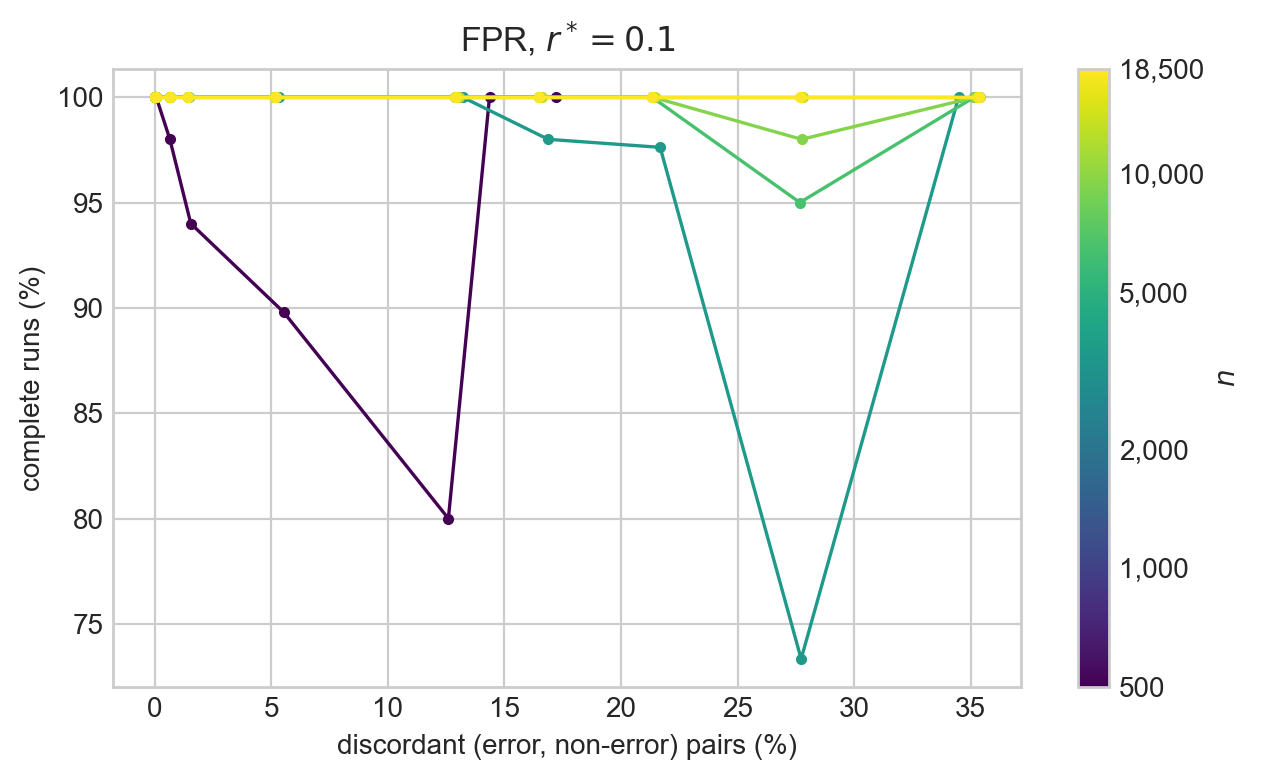

In [11]:
sub = res[res.r_star == PLOT_R_STAR]
ns = sorted(sub.n.unique())
cnorm, cmap = LogNorm(vmin=min(ns), vmax=max(ns)), plt.cm.viridis

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(6.5, 4), dpi=200)
    for n, g in sub.groupby("n"):
        m = g.groupby("ranking")[["discordant", "complete"]].mean().dropna()
        m = m.sort_values("discordant")
        ax.plot(
            m.discordant,
            100 * m.complete,
            marker="o",
            ms=3,
            lw=1.2,
            color=cmap(cnorm(n)),
        )
    ax.set_xlabel("discordant (error, non-error) pairs (%)")
    ax.set_ylabel("complete runs (%)")
    ticks = sorted(
        {min(ns), 1000, 2000, 5000, 10000, max(ns)} & set(range(min(ns), max(ns) + 1))
    )
    cbar = fig.colorbar(ScalarMappable(norm=cnorm, cmap=cmap), ax=ax, ticks=ticks)
    cbar.ax.minorticks_off()
    cbar.ax.set_yticklabels([f"{t:,}" for t in ticks])
    cbar.set_label("$n$")
    plt.title(f"{METRIC}, $r^*={PLOT_R_STAR}$")
    plt.tight_layout()
    plt.show()